# Station-MAE — Pipeline Exploration

Step-by-step walkthrough of the full stack:
data loading → spatial/temporal embeddings → encoder → decoder → mini-training → evaluation.

**Set `DATA_ROOT` (and optionally `PATH_SWISSSHAPE`) in the Config cell before running.**

**v9 setup:** W=72 (12 h input), K=13 fixed-grid horizons [now, 30 min, … 6 h], NLL loss.

In [1]:
import sys, math, os
# ── Project bootstrap ────────────────────────────────────────────────────────
# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once).
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import (
    ModelCheckpoint, EarlyStopping, LearningRateMonitor,
)

# ── User config ────────────────────────────────────────────────────────────
DATA_ROOT       = "/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset"
PATH_SWISSSHAPE = "/Users/aureliedejong/Documents/ETH/_DAS Project/swissboundaries3d_2026-01_2056_5728.shp.zip"

# Window / forecast  (matches run_full_cloud.sh tw6-d1024-v9)
WINDOW_SIZE      = 72     # 12 h of input context  (72 × 10 min)
MAX_DELTA_STEPS  = 36     # max lead-time: 6 h      (36 × 10 min)
DELTA_MODE       = "fixed_grid"
DELTA_GRID_STRIDE = 3     # 30-min spacing → K=13 horizons: [0, 3, 6, …, 36]
# delta_grid = [0, 3, 6, …, 36]  (K=13)
#   k=0  → delta=0  : inpainting / gap-filling (loss on masked stations only)
#   k=1  → delta=3  : 30-min forecast (primary monitoring metric)
#   k=12 → delta=36 : 6-h forecast

# Subset mode — set to True to train on 2 years only (pipeline sanity check).
SUBSET_MODE  = True
SUBSET_YEARS = [2020, 2021]

# Model — the TRAINED configuration (run_full_cloud.sh, tw6-d1024-v9/v11/v12) is:
#     d_model=1024, enc_heads=16, enc_layers=8, dec_heads=16, dec_layers=2,
#     mlp_ratio=4.0, temporal_window=6, cross_attn_decoder, input_context_cross_attn
# Here we run a SMALL version so the notebook is laptop-friendly, but keep the
# same structural switches (windowed attention, cross-attn decoder) so what we
# inspect matches what is trained.
BATCH_SIZE   = 8
D_MODEL      = 128        # trained: 1024
ENC_HEADS    = 4          # trained: 16
ENC_LAYERS   = 4          # trained: 8
DEC_HEADS    = 4          # trained: 16
DEC_LAYERS   = 2          # trained: 2
MLP_RATIO    = 4.0
TEMPORAL_WINDOW = 6       # ← windowed (Swin-shifted) attention: 6 steps × N stations
                          #    per chunk. 0 = full flat attention over W·N tokens.

# Mini-training
MINI_SAVE_DIR = "./checkpoints_mini"   # checkpoints + Lightning logs

print("Imports OK")

# Device priority: CUDA > MPS > CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built() else
    "cpu"
)
print(f"Device: {device}  |  Lightning {pl.__version__}")

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cuda.enable_flash_sdp(True)
    print("  CUDA optimisations enabled (TF32, Flash Attention)")

if SUBSET_MODE:
    print(f"[Subset mode]  Training years: {SUBSET_YEARS}")

_K = (MAX_DELTA_STEPS // DELTA_GRID_STRIDE) + 1   # 13
print(f"Delta grid: K={_K} horizons  [{', '.join(str(i) for i in range(0, MAX_DELTA_STEPS+1, DELTA_GRID_STRIDE))}] steps")

Imports OK
Device: mps  |  Lightning 2.6.1
[Subset mode]  Training years: [2020, 2021]
Delta grid: K=13 horizons  [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36] steps


## Step 1 — Load PeakWeather dataset

In [2]:
from data.dataset import (
    load_peakweather, build_spatial_features, build_observations,
    normalise_observations, compute_obs_stats, StationMAEDataset,
    VARIABLE_NAMES, NUM_VARIABLES, TRAIN_YEARS,
)

ds = load_peakweather(DATA_ROOT)
print(ds)
print(f"\nStations  : {ds.num_stations}")
print(f"Timesteps : {ds.num_time_steps}")
print(f"Parameters:")
ds.show_parameters_description()

PeakWeatherDataset(num_time_steps=461952, num_stations=156, num_parameters=8)

Stations  : 156
Timesteps : 461952
Parameters:
          name param_short                                                                    Description
      humidity    ure200s0               Relative air humidity 2 m above ground; current value (per cent)
 precipitation    rre150z0                                  Precipitation; ten minutes total (millimeter)
      pressure    prestas0 Atmospheric pressure at barometric altitude (QFE); current value (hectopascal)
   temperature    tre200s0               Air temperature 2 m above ground; current value (degree Celsius)
wind_direction    dkl010z0                                      Wind direction; ten minutes mean (degree)
    wind_speed    fkl010z0                      Wind speed scalar; ten minutes mean in m/s (meter/second)
        wind_u  fkl010z0_u                                  u component (E-W) of the wind. (meter/second)
        wind_v  fkl010z0_v

In [3]:
print("Number of spatial variables: ", len(ds.stations_table.columns), "\n", list(ds.stations_table.columns))

Number of spatial variables:  20 
 ['station_name', 'latitude', 'longitude', 'station_height', 'swiss_easting', 'swiss_northing', 'ASPECT_2000M_SIGRATIO1', 'WE_DERIVATIVE_2000M_SIGRATIO1', 'TPI_2000M', 'SN_DERIVATIVE_10000M_SIGRATIO1', 'dem', 'SN_DERIVATIVE_2000M_SIGRATIO1', 'SLOPE_10000M_SIGRATIO1', 'ASPECT_10000M_SIGRATIO1', 'SLOPE_2000M_SIGRATIO1', 'STD_2000M', 'STD_10000M', 'TPI_10000M', 'WE_DERIVATIVE_10000M_SIGRATIO1', 'station_type']


In [4]:
ds.stations_table.head()

,station_name,latitude,longitude,station_height,swiss_easting,swiss_northing,ASPECT_2000M_SIGRATIO1,WE_DERIVATIVE_2000M_SIGRATIO1,TPI_2000M,SN_DERIVATIVE_10000M_SIGRATIO1,dem,SN_DERIVATIVE_2000M_SIGRATIO1,SLOPE_10000M_SIGRATIO1,ASPECT_10000M_SIGRATIO1,SLOPE_2000M_SIGRATIO1,STD_2000M,STD_10000M,TPI_10000M,WE_DERIVATIVE_10000M_SIGRATIO1,station_type
nat_abbr,,,,,,,,,,,,,,,,,,,,
ABO,Adelboden,46.491703,7.560703,1321.38,2.609372e+06,1.148939e+06,124.863129,-0.167379,-53.303345,-0.026807,1317.771851,0.116605,1.702339,25.582031,11.529667,120.940262,374.830623,-443.723877,-0.012833,meteo_station
AEG,Oberägeri,47.133636,8.608206,724.43,2.688729e+06,1.220956e+06,190.899567,0.010865,-20.030273,-0.013760,724.173462,0.056423,1.099379,315.811829,3.288559,27.269887,141.396220,-165.792114,0.013376,meteo_station
AIG,Aigle,46.326647,6.924472,381.02,2.560403e+06,1.130714e+06,301.137115,0.002014,-0.256348,0.006587,381.100006,-0.001216,0.760270,119.760574,0.134786,0.000000,287.689425,-195.166718,-0.011520,meteo_station
ALT,Altdorf,46.887069,8.621894,437.86,2.690181e+06,1.193563e+06,240.803589,0.020179,-2.120819,-0.009294,438.587494,0.011276,0.995863,57.677086,1.324231,0.000000,493.449619,-518.464722,-0.014689,meteo_station
AND,Andeer,46.610139,9.431981,987.10,2.752692e+06,1.164037e+06,285.070679,0.079193,-57.052063,-0.033264,984.354675,-0.021324,2.702750,314.800964,4.688558,71.570846,459.982181,-745.938782,0.033496,meteo_station


## Step 2 — Visualise stations on DEM

```python
from data.visualize import plot_stations_on_dem, markers_from_stations_table

all_markers = markers_from_stations_table(
    ds.stations_table,
    default_color="steelblue",
    size=20,
    label="Meteo stations",
)

plot_stations_on_dem(
    ds,
    stations=all_markers,
    path_swissshape=PATH_SWISSSHAPE,
    title="PeakWeather — All Meteo Stations",
)
plt.show()
```

## Step 3 — Spatial features  `(N, 15)`

In [5]:
spatial, spatial_stats = build_spatial_features(ds)
N = spatial.shape[0]

print(f"spatial shape : {tuple(spatial.shape)}")
print(f"mean  (≈ 0)   : {spatial.mean(0).abs().max():.6f}")
print(f"std   (≈ 1)   : {spatial.std(0).mean():.6f}")
print()
print("Feature layout (15 dims):")
layout = [
    "swiss_easting", "swiss_northing",
    "sin(aspect 2km)", "cos(aspect 2km)", "sin(aspect 10km)", "cos(aspect 10km)",
    "station_height", "dem", "TPI_2000m",
    "slope_2km", "slope_10km", "SN_deriv_2km", "SN_deriv_10km",
    "WE_deriv_2km", "WE_deriv_10km",
]
for i, name in enumerate(layout[:spatial.shape[1]]):
    print(f"  [{i:2d}] {name}")

spatial shape : (156, 15)
mean  (≈ 0)   : 0.000002
std   (≈ 1)   : 1.000000

Feature layout (15 dims):
  [ 0] swiss_easting
  [ 1] swiss_northing
  [ 2] sin(aspect 2km)
  [ 3] cos(aspect 2km)
  [ 4] sin(aspect 10km)
  [ 5] cos(aspect 10km)
  [ 6] station_height
  [ 7] dem
  [ 8] TPI_2000m
  [ 9] slope_2km
  [10] slope_10km
  [11] SN_deriv_2km
  [12] SN_deriv_10km
  [13] WE_deriv_2km
  [14] WE_deriv_10km


In [6]:
spatial_stats

{'mean': tensor([ 2.6621e+06,  1.1825e+06, -5.6574e-02, -1.7042e-01, -6.8261e-02,
          5.1764e-02,  1.0522e+03,  1.0495e+03,  2.8322e+00,  5.0896e+00,
          2.5845e+00,  2.4399e-02, -4.6782e-04,  9.5552e-03,  4.8143e-03]),
 'std': tensor([7.8817e+04, 5.0829e+04, 6.6287e-01, 7.3117e-01, 6.7992e-01, 7.3265e-01,
         7.6075e+02, 7.5644e+02, 1.0911e+02, 5.0903e+00, 2.0809e+00, 8.6525e-02,
         4.2030e-02, 9.1694e-02, 4.0033e-02])}

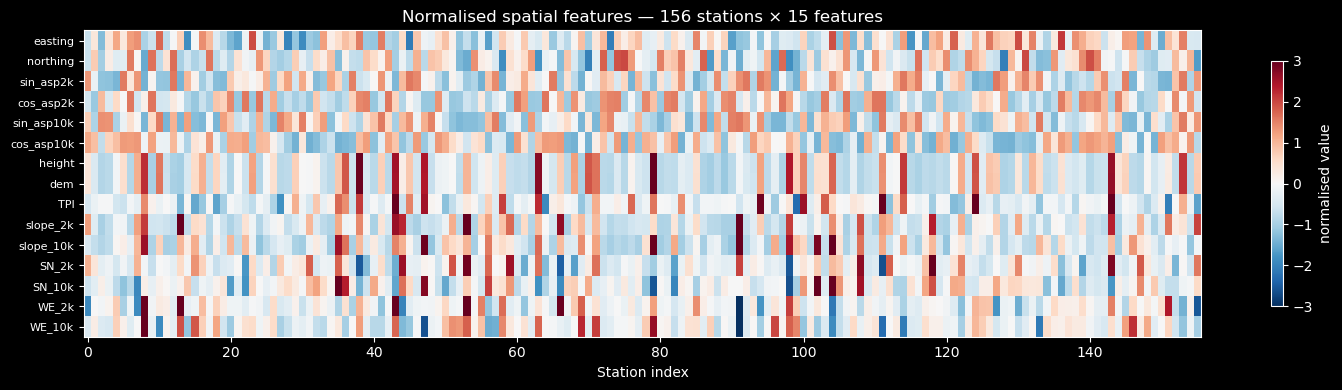

spatial tensor: (156, 15)  dtype=torch.float32


In [7]:
labels_15 = [
    "easting","northing",
    "sin_asp2k","cos_asp2k","sin_asp10k","cos_asp10k",
    "height","dem","TPI",
    "slope_2k","slope_10k","SN_2k","SN_10k","WE_2k","WE_10k",
]

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(spatial.T.numpy(), aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_yticks(range(spatial.shape[1]))
ax.set_yticklabels(labels_15, fontsize=8)
ax.set_xlabel("Station index")
ax.set_title(f"Normalised spatial features — {spatial.shape[0]} stations × 15 features")
plt.colorbar(im, ax=ax, shrink=0.8, label="normalised value")
plt.tight_layout()
plt.show()
print(f"spatial tensor: {tuple(spatial.shape)}  dtype={spatial.dtype}")

## Step 4 — Temporal encoding (Fourier)

`encode_temporal(ts)` → **hours since 1970-01-01 UTC** (a single float).
`TemporalEmbedding` then expands this scalar into log-spaced Fourier features
spanning λ_min = 10 min → λ_max = 1 year, capturing diurnal, weekly, monthly and seasonal cycles.

In [8]:
from model.embeddings import encode_temporal, TemporalEmbedding, TEMPORAL_FOURIER_DIM

# Single timestamp example
ts_ex = pd.Timestamp("2021-06-21 12:00:00+00:00")
h_ex  = encode_temporal(ts_ex)
print(f"encode_temporal('{ts_ex}')  =  {h_ex:.2f} h since epoch")
print(f"  ≈ {h_ex / 8766:.2f} years since 1970-01-01")

# Fourier module configuration
n_wl       = TEMPORAL_FOURIER_DIM // 2
lambda_min = 1.0 / 6.0
lambda_max = 365.25 * 24.0
lambdas    = torch.exp(torch.linspace(math.log(lambda_min), math.log(lambda_max), n_wl))
print(f"\nFourier dim    : {TEMPORAL_FOURIER_DIM}  ({n_wl} wavelengths)")
print(f"λ_min          : {lambda_min:.4f} h  ({lambda_min*60:.0f} min)")
print(f"λ_max          : {lambda_max:.1f} h  ({lambda_max/24:.1f} days ≈ 1 year)")
print(f"λ values (h)   : {[f'{l:.1f}' for l in lambdas.tolist()]}")

encode_temporal('2021-06-21 12:00:00+00:00')  =  451188.00 h since epoch
  ≈ 51.47 years since 1970-01-01

Fourier dim    : 32  (16 wavelengths)
λ_min          : 0.1667 h  (10 min)
λ_max          : 8766.0 h  (365.2 days ≈ 1 year)
λ values (h)   : ['0.2', '0.3', '0.7', '1.5', '3.0', '6.2', '12.9', '26.6', '54.9', '113.3', '234.0', '482.9', '996.8', '2057.5', '4246.9', '8766.0']


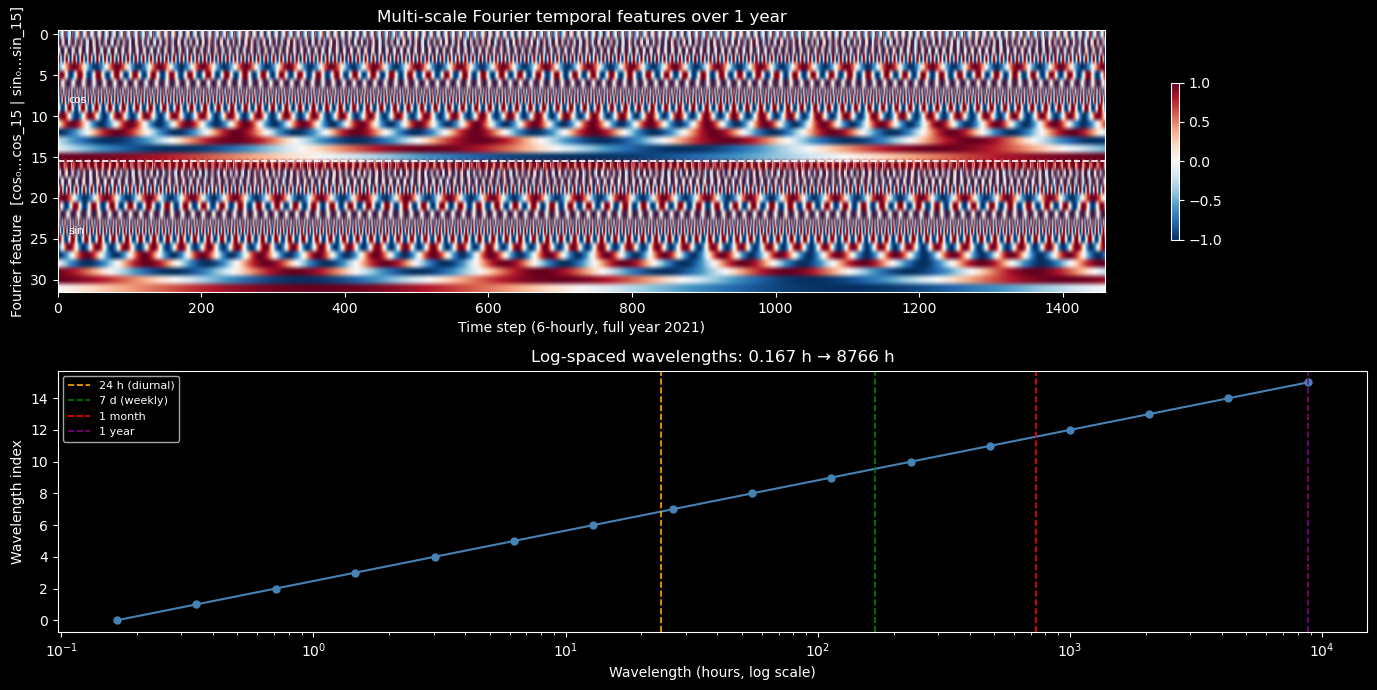

In [9]:
# Visualise Fourier features over a full year sampled every 6 hours
start   = pd.Timestamp("2021-01-01 00:00:00+00:00")
n_steps = 365 * 4                                          # 4 samples/day × 365 days
times   = [start + pd.Timedelta(hours=6*i) for i in range(n_steps)]
h_arr   = torch.tensor([encode_temporal(ts) for ts in times])  # (n_steps,)

temp_mod = TemporalEmbedding(d_model=D_MODEL, fourier_dim=TEMPORAL_FOURIER_DIM)
with torch.no_grad():
    fourier = temp_mod._fourier(h_arr)    # (n_steps, TEMPORAL_FOURIER_DIM)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top — Fourier feature matrix over time
ax = axes[0]
im = ax.imshow(fourier.numpy().T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("Time step (6-hourly, full year 2021)")
ax.set_ylabel(f"Fourier feature  [cos₀…cos_{n_wl-1} | sin₀…sin_{n_wl-1}]")
ax.axhline(n_wl - 0.5, color="white", linewidth=1.2, linestyle="--")
ax.text(n_steps * 0.01, n_wl * 0.5, "cos", color="white", fontsize=8, va="center")
ax.text(n_steps * 0.01, n_wl + n_wl * 0.5, "sin", color="white", fontsize=8, va="center")
ax.set_title("Multi-scale Fourier temporal features over 1 year")
plt.colorbar(im, ax=ax, shrink=0.6)

# Bottom — log-spaced wavelengths with reference lines
ax2 = axes[1]
ax2.semilogx(lambdas.numpy(), range(n_wl), "o-", markersize=5, color="steelblue")
for lam, label, color in [
    (24,        "24 h (diurnal)",  "orange"),
    (24*7,      "7 d (weekly)",    "green"),
    (24*30.5,   "1 month",         "red"),
    (24*365.25, "1 year",          "purple"),
]:
    ax2.axvline(lam, color=color, linestyle="--", linewidth=1.2, label=label)
ax2.set_xlabel("Wavelength (hours, log scale)")
ax2.set_ylabel("Wavelength index")
ax2.set_title(f"Log-spaced wavelengths: {lambda_min:.3f} h → {lambda_max:.0f} h")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 5 — Full observation tensor  `(T, N, V)`

In [10]:
obs_full, mask_full, timestamps_full = build_observations(ds)
T, N, V = obs_full.shape

print(f"obs  shape  : {tuple(obs_full.shape)}   (T, N, V)")
print(f"mask shape  : {tuple(mask_full.shape)}")
print(f"Time range  : {timestamps_full[0]}  →  {timestamps_full[-1]}")
print(f"Resolution  : 10 min")
print()

# Per-variable availability
print(f"{'Variable':<16}  {'% present':>10}  {'bar'}")
print("-" * 50)
for v, name in enumerate(VARIABLE_NAMES):
    pct = 100.0 * mask_full[:, :, v].float().mean().item()
    bar = "█" * int(pct / 5)
    print(f"  {name:<14}  {pct:>9.1f}%  {bar}")

obs  shape  : (461952, 156, 6)   (T, N, V)
mask shape  : (461952, 156, 6)
Time range  : 2017-01-01 00:00:00+00:00  →  2025-10-13 23:50:00+00:00
Resolution  : 10 min

Variable           % present  bar
--------------------------------------------------
  temperature          95.3%  ███████████████████
  pressure             88.5%  █████████████████
  humidity             95.2%  ███████████████████
  wind_u               96.0%  ███████████████████
  wind_v               96.0%  ███████████████████
  precipitation        88.4%  █████████████████


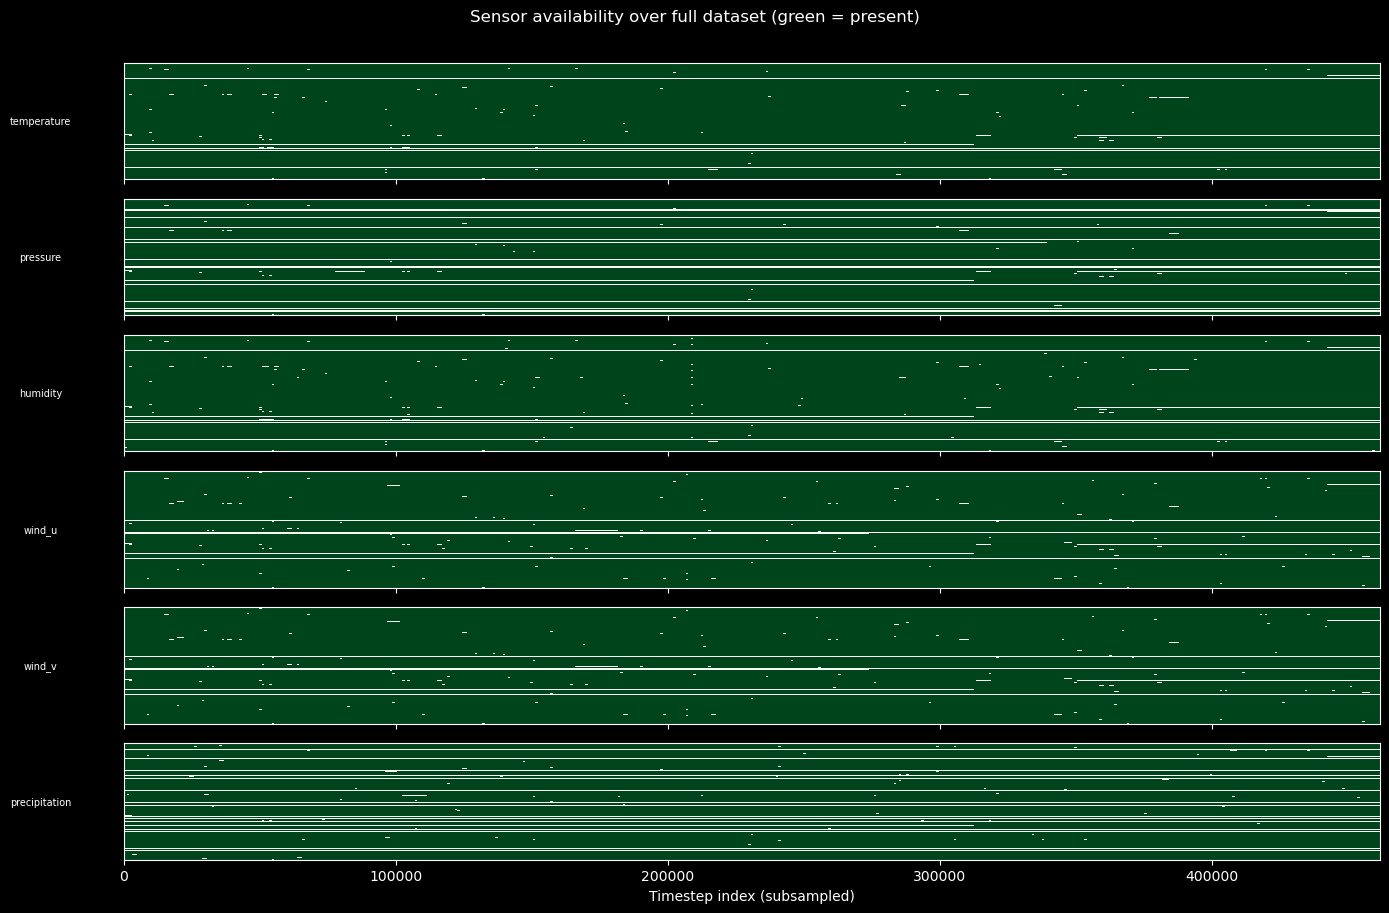

In [11]:
# Per-variable availability heatmap across time (subsampled)
stride = max(1, T // 500)

fig, axes = plt.subplots(V, 1, figsize=(14, V * 1.5), sharex=True)
for v, name in enumerate(VARIABLE_NAMES):
    ax  = axes[v]
    mat = mask_full[::stride, :, v].numpy()    # (T', N)
    ax.imshow(mat.T, aspect="auto", cmap="Greens", vmin=0, vmax=1,
              interpolation="none", extent=[0, T, N, 0])
    ax.set_ylabel(name, fontsize=7, rotation=0, labelpad=60, va="center")
    ax.set_yticks([])

axes[-1].set_xlabel("Timestep index (subsampled)")
fig.suptitle("Sensor availability over full dataset (green = present)", y=1.01)
plt.tight_layout(); plt.show()

## Step 6 — Normalisation (per-station, train split stats)

`obs_stats["mean"]` and `obs_stats["std"]` are `(N, V)` per-station tensors (v5 cache).
The display below averages across stations for a single representative value per variable.

In [12]:
# Compute normalisation statistics from the TRAINING split only (2017–2021).
# obs_stats["mean"] / ["std"] are now (N, V) per-station-per-variable tensors.
_train_years = SUBSET_YEARS if SUBSET_MODE else None
obs_stats = compute_obs_stats(ds, train_years=_train_years)

mean_t = obs_stats["mean"]   # (N, V)  or (V,) for old caches
std_t  = obs_stats["std"]

# Compute per-variable mean/std averaged across stations for display
if mean_t.dim() == 2:         # per-station (N, V) — current format
    mean_display = mean_t.mean(0)   # (V,)
    std_display  = std_t.mean(0)    # (V,)
    print(f"obs_stats shape : (N={mean_t.shape[0]}, V={mean_t.shape[1]}) — per-station normalisation")
else:                          # legacy global (V,)
    mean_display = mean_t
    std_display  = std_t
    print(f"obs_stats shape : (V={mean_t.shape[0]}) — global normalisation (legacy)")

print()
print(f"{'Variable':<16}  {'mean (avg across stations)':>28}  {'std':>10}  {'unit (raw)'}")
print("-" * 72)
units = ["°C", "hPa", "%", "m/s", "m/s", "mm"]
for v, name in enumerate(VARIABLE_NAMES):
    m = mean_display[v].item()
    s = std_display[v].item()
    print(f"  {name:<14}  {m:>28.4f}  {s:>10.4f}  {units[v]}")

print()
print("After normalisation: mean ≈ 0,  std ≈ 1 per station (training-split statistics).")

obs_stats shape : (N=156, V=6) — per-station normalisation

Variable            mean (avg across stations)         std  unit (raw)
------------------------------------------------------------------------
  temperature                           7.4088      7.5521  °C
  pressure                            898.4661     16.0788  hPa
  humidity                             74.9080     19.6562  %
  wind_u                                0.3598      2.2496  m/s
  wind_v                                0.0579      2.1302  m/s
  precipitation                         0.0226      0.1495  mm

After normalisation: mean ≈ 0,  std ≈ 1 per station (training-split statistics).


## Step 7 — StationMAEDataset

**v9 configuration:**
- `delta_mode="fixed_grid"` — every sample returns K=13 targets at [0, 30 min, 1 h, … 6 h]
- `index_mode="random"` for train (Aurora-style per-item sampling with replacement)
- `index_mode="blocks"` for val (non-overlapping windows, reproducible)
- `exclude_stations=["PFA"]` — station with insufficient coverage (set in full runs)

In [13]:
# obs_stats was computed from the training split above — pass to all splits so
# val/test are normalised with the same scale.

train_ds = StationMAEDataset(
    ds,
    window_size=WINDOW_SIZE,
    delta_steps=MAX_DELTA_STEPS,
    split="train",
    obs_stats=obs_stats,
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,
    shared_memory=False,
    index_mode="random",                  # Aurora-style: uniform random sampling per item
    delta_mode=DELTA_MODE,                # "fixed_grid"
    delta_grid_stride=DELTA_GRID_STRIDE,  # 30-min spacing → K=13
)
val_ds = StationMAEDataset(
    ds,
    window_size=WINDOW_SIZE,
    delta_steps=MAX_DELTA_STEPS,
    split="val",
    obs_stats=train_ds.obs_stats,         # always normalise with training-split stats
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,
    shared_memory=False,
    index_mode="blocks",                  # non-overlapping windows for val
    delta_mode=DELTA_MODE,
    delta_grid_stride=DELTA_GRID_STRIDE,
)
test_ds = StationMAEDataset(
    ds,
    window_size=WINDOW_SIZE,
    delta_steps=MAX_DELTA_STEPS,
    split="test",
    obs_stats=train_ds.obs_stats,
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,
    shared_memory=False,
    index_mode="blocks",
    delta_mode=DELTA_MODE,
    delta_grid_stride=DELTA_GRID_STRIDE,
)

K = len(train_ds.delta_grid)
print(f"Subset mode   : {SUBSET_MODE}  (train years: {_train_years or 'all 2017–2021'})")
print(f"Train samples : {len(train_ds):,}  (index_mode=random, random_epoch_size=None)")
print(f"Val   samples : {len(val_ds):,}    (index_mode=blocks, non-overlapping)")
print(f"Test  samples : {len(test_ds):,}")
print(f"Window size W : {train_ds.window_size} steps = {train_ds.window_size * 10 / 60:.1f} h")
print(f"Delta grid    : K={K}  horizons: {train_ds.delta_grid}")
print(f"  k=0  (delta=0 ) → inpainting  (loss on masked stations only)")
print(f"  k=1  (delta=3 ) → 30-min forecast  (primary monitoring metric)")
print(f"  k=12 (delta=36) → 6-h   forecast")

[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.9s  (obs (461952, 156, 6))
[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.6s  (obs (461952, 156, 6))
[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.6s  (obs (461952, 156, 6))
Subset mode   : True  (train years: [2020, 2021])
Train samples : 1,460  (index_mode=random, random_epoch_size=None)
Val   samples : 729    (index_mode=blocks, non-overlapping)
Test  samples : 1,461
Window size W : 72 steps = 12.0 h
Delta grid    : K=13  horizons: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]
  k=0  (delta=0 ) → inpainting  (loss on masked stations only)
  k=1  (delta=3 ) → 30-min forecast  (primary monitoring metric)
  k=12 (delta=36) → 6-h   forecast


Sample keys and shapes:
  x                (72, 156, 6)  dtype=torch.float32
  x_mask           (72, 156, 6)  dtype=torch.float32
  x_hours          (72,)  dtype=torch.float32
  y                (13, 156, 6)  dtype=torch.float32
  y_mask           (13, 156, 6)  dtype=torch.float32
  y_hours          (13,)  dtype=torch.float32
  spatial          (156, 15)  dtype=torch.float32
  delta_steps      (13,)  dtype=torch.int64

delta_steps (K=13): [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]
  → lead times: ['0 (inpainting)', '0h30m', '1h00m', '1h30m', '2h00m', '2h30m', '3h00m', '3h30m', '4h00m', '4h30m', '5h00m', '5h30m', '6h00m']


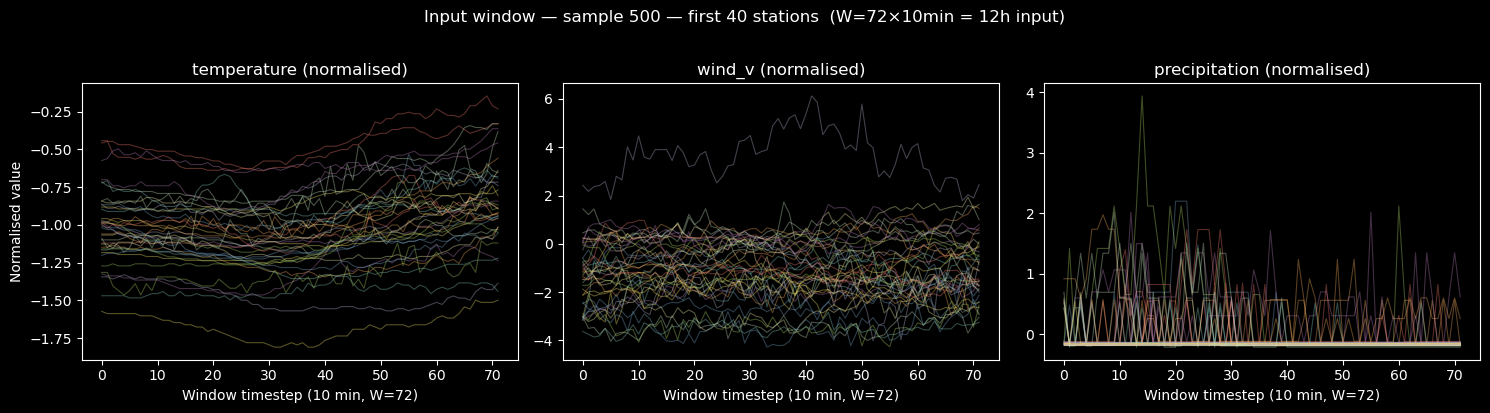

In [14]:
# Inspect one sample — fixed_grid returns K=13 targets per sample
sample  = train_ds[500]
print("Sample keys and shapes:")
for key, val in sample.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<16} {tuple(val.shape)}  dtype={val.dtype}")

W_s, N_s, V_s = sample["x"].shape
K_s = sample["delta_steps"].shape[0]
print(f"\ndelta_steps (K={K_s}): {sample['delta_steps'].tolist()}")
print(f"  → lead times: {[f'{d*10//60}h{d*10%60:02d}m' if d>0 else '0 (inpainting)' for d in sample['delta_steps'].tolist()]}")

# Plot input window for one sample — temperature across stations
x       = sample["x"]       # (W, N, V)
x_mask  = sample["x_mask"]  # (W, N, V)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, (var_idx, title) in enumerate([(0, "temperature"), (4, "wind_v"), (5, "precipitation")]):
    ax = axes[col]
    for n in range(min(N_s, 40)):
        present = x_mask[:, n, var_idx].bool()
        vals    = x[:, n, var_idx].clone().numpy().astype(float)
        vals[~present.numpy()] = float("nan")
        ax.plot(vals, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{title} (normalised)")
    ax.set_xlabel(f"Window timestep (10 min, W={W_s})")
    if col == 0:
        ax.set_ylabel("Normalised value")

plt.suptitle(f"Input window — sample 500 — first 40 stations  (W={W_s}×10min = {W_s*10//60}h input)", y=1.02)
plt.tight_layout(); plt.show()

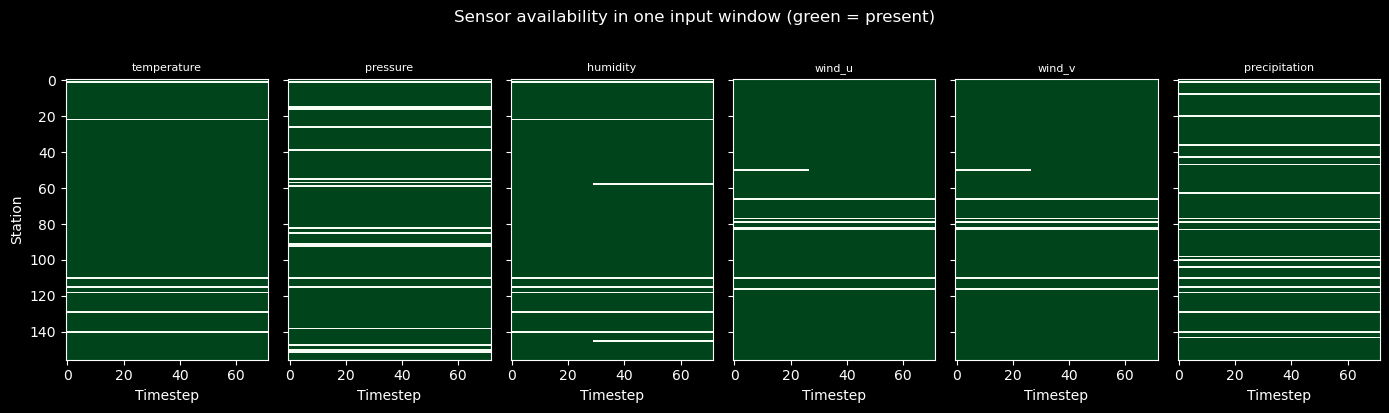


Target at k=1 (delta=3 = 30 min):  y.shape=(156, 6), sensor coverage=95.5%


In [15]:
# Missing data heatmap across the input window for the same sample
fig, axes = plt.subplots(1, V_s, figsize=(14, 4), sharey=True)
for v_idx, var in enumerate(VARIABLE_NAMES):
    ax  = axes[v_idx]
    mat = x_mask[:, :, v_idx].numpy()   # (W, N)
    ax.imshow(mat.T, aspect="auto", cmap="Greens", vmin=0, vmax=1,
              interpolation="none")
    ax.set_title(var, fontsize=8)
    ax.set_xlabel("Timestep")
    if v_idx == 0:
        ax.set_ylabel("Station")

fig.suptitle("Sensor availability in one input window (green = present)", y=1.02)
plt.tight_layout(); plt.show()

# Show one of the K=13 targets (k=1 → delta=3 = 30 min forecast)
y_k1 = sample["y"][1]         # (N, V)  target at 30 min
ym_k1 = sample["y_mask"][1]   # (N, V)
print(f"\nTarget at k=1 (delta=3 = 30 min):  y.shape={tuple(y_k1.shape)}, "
      f"sensor coverage={ym_k1[:, 0].float().mean():.1%}")

## Step 8 — Embeddings

Five embeddings are summed per decoder query token:
- **Variable** `VariableProjection` — *what* was measured (encoder input only)
- **Spatial p1** `PositionalEmbedding` — *where* (Fourier over easting/northing)
- **Spatial p2** `StationEmbedding` — *where* (MLP over topographic characteristics)
- **Temporal** `TemporalEmbedding` — *when* (Aurora Fourier absolute time, shared)
- **Delta** `DeltaTimeEmbedding` — forecast lead-time in hours (Fourier-based)
- **Step** `StepIndexEmbedding` — *integer position* in the unified encoder+decoder
  timeline (encoder: steps 0…W-1=71; decoder queries: steps W-1+Δ = 74, 77, …, 107)

In [16]:
from model.embeddings import (
    PositionalEmbedding, StationEmbedding,
    TemporalEmbedding, VariableProjection, DeltaTimeEmbedding, StepIndexEmbedding,
    TEMPORAL_FOURIER_DIM, DELTA_FOURIER_DIM,
    POSITION_FOURIER_DIM, STATION_CHAR_DIM,
    TARGET_VARIABLE_NAMES, NUM_TARGET_VARIABLES,
)

pos_emb     = PositionalEmbedding(d_model=D_MODEL, fourier_dim=POSITION_FOURIER_DIM)
station_emb = StationEmbedding(d_model=D_MODEL, input_dim=STATION_CHAR_DIM)
temporal_emb = TemporalEmbedding(d_model=D_MODEL, fourier_dim=TEMPORAL_FOURIER_DIM)
var_proj     = VariableProjection(num_vars=NUM_VARIABLES, d_model=D_MODEL)
delta_emb    = DeltaTimeEmbedding(d_model=D_MODEL, fourier_dim=DELTA_FOURIER_DIM)
step_emb     = StepIndexEmbedding(d_model=D_MODEL)   # shared encoder/decoder timeline

sp_in   = spatial.unsqueeze(0)              # (1, N, 15) — add batch dimension
x_in    = sample["x"].unsqueeze(0)          # (1, W, N, V)
xm_in   = sample["x_mask"].unsqueeze(0)     # (1, W, N, V)
hrs_in  = sample["x_hours"].unsqueeze(0)    # (1, W)
W = x_in.shape[1]

with torch.no_grad():
    vp_out  = var_proj(x_in.view(1 * W, N_s, V_s),
                       xm_in.view(1 * W, N_s, V_s)).view(1, W, N_s, D_MODEL)
    p1_out  = pos_emb(sp_in[..., :2])           # (1, N, d_model)
    p2_out  = station_emb(sp_in[..., 2:])       # (1, N, d_model)
    tp_out  = temporal_emb(hrs_in)              # (1, W, d_model)
    # StepIndexEmbedding — encoder uses indices 0..W-1
    enc_step_idx = torch.arange(W, dtype=torch.long)   # (W,)
    se_out  = step_emb(enc_step_idx)            # (W, d_model)
    # Decoder would use W-1+delta: e.g. delta=3 → idx=74, delta=36 → idx=107
    dec_step_idx = (WINDOW_SIZE - 1) + torch.tensor([0, 3, 6, 36], dtype=torch.long)
    dec_se_out = step_emb(dec_step_idx)         # (4, d_model)

print(f"v  VariableProjection  : {tuple(vp_out.shape)}   (B, W, N, d_model)")
print(f"p1 PositionalEmbedding : {tuple(p1_out.shape)}      (B, N, d_model)")
print(f"p2 StationEmbedding    : {tuple(p2_out.shape)}      (B, N, d_model)")
print(f"t  TemporalEmbedding   : {tuple(tp_out.shape)}      (B, W, d_model)")
print(f"s  StepIndexEmbedding  : {tuple(se_out.shape)}       (W, d_model)  — encoder steps 0..{W-1}")
print(f"   (decoder queries)   : {tuple(dec_se_out.shape)}       steps {dec_step_idx.tolist()} for Δ=[0,3,6,36]")
print()
print("Encoder token = v + p1 + p2 + t + s")
print("Decoder query = mask_token + p1 + p2 + t + Δ_emb + s  (W-1+Δ position)")

v  VariableProjection  : (1, 72, 156, 128)   (B, W, N, d_model)
p1 PositionalEmbedding : (1, 156, 128)      (B, N, d_model)
p2 StationEmbedding    : (1, 156, 128)      (B, N, d_model)
t  TemporalEmbedding   : (1, 72, 128)      (B, W, d_model)
s  StepIndexEmbedding  : (72, 128)       (W, d_model)  — encoder steps 0..71
   (decoder queries)   : (4, 128)       steps [71, 74, 77, 107] for Δ=[0,3,6,36]

Encoder token = v + p1 + p2 + t + s
Decoder query = mask_token + p1 + p2 + t + Δ_emb + s  (W-1+Δ position)


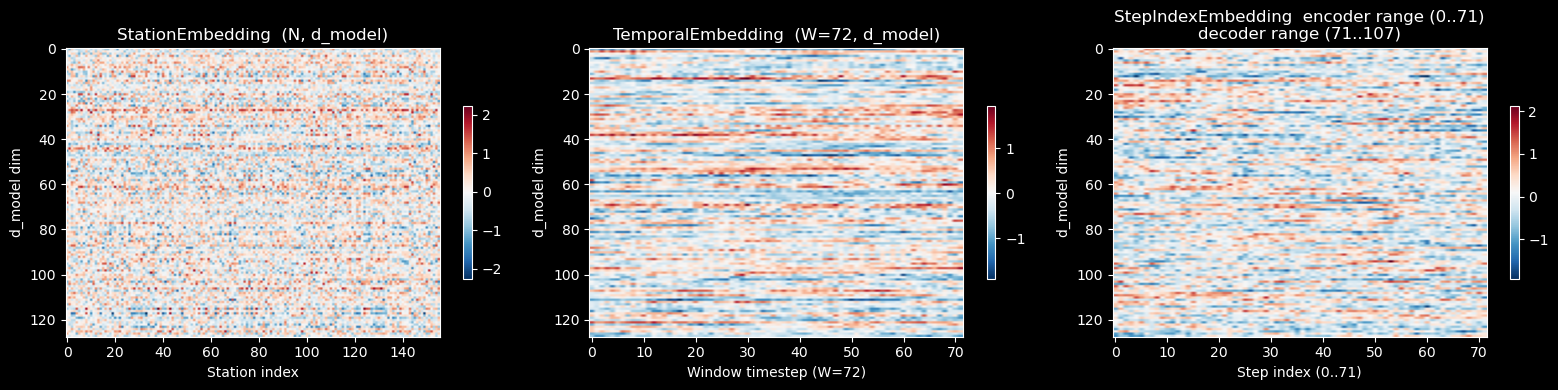

In [17]:
# Visualise embedding components
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Spatial embedding heatmap (all stations)
ax = axes[0]
im = ax.imshow(p2_out[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Station index"); ax.set_ylabel("d_model dim")
ax.set_title("StationEmbedding  (N, d_model)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Temporal embedding heatmap (all window steps)
ax = axes[1]
im = ax.imshow(tp_out[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel(f"Window timestep (W={W})")
ax.set_ylabel("d_model dim")
ax.set_title(f"TemporalEmbedding  (W={W}, d_model)")
plt.colorbar(im, ax=ax, shrink=0.6)

# StepIndexEmbedding for encoder (0..W-1) — shows the positional ramp
ax = axes[2]
im = ax.imshow(se_out.detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel(f"Step index (0..{W-1})")
ax.set_ylabel("d_model dim")
ax.set_title(f"StepIndexEmbedding  encoder range (0..{W-1})\ndecoder range ({WINDOW_SIZE-1}..{WINDOW_SIZE-1+MAX_DELTA_STEPS})")
plt.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout(); plt.show()

## Step 9 — Encoder forward pass

The encoder returns **4 values**:
- `encoded` : `(B, W*N_vis, d_model)` — visible tokens after transformer blocks
- `masked_idx` : `(B, N_masked)` — station indices that were masked
- `visible_idx` : `(B, N_vis)` — station indices that were visible
- `input_context` : `(B, N, d_model)` — last-step embeddings for visible stations (zeros for masked); used by decoder cross-attention

In [18]:
from model.encoder import StationMAEEncoder

encoder = StationMAEEncoder(
    d_model=D_MODEL, num_heads=ENC_HEADS, num_layers=ENC_LAYERS,
    mlp_ratio=MLP_RATIO, dropout=0.0, mask_ratio=0.5,
    temporal_window=TEMPORAL_WINDOW,   # windowed + Swin half-shift (as trained)
)
print(f"Encoder attention: "
      + (f"windowed, chunks of {TEMPORAL_WINDOW} steps × N stations "
         f"({WINDOW_SIZE//TEMPORAL_WINDOW} chunks), Swin half-shift on odd layers"
         if TEMPORAL_WINDOW else "full flat attention over W·N tokens"))
print(f"Encoder parameters: {sum(p.numel() for p in encoder.parameters()):,}")

encoder.eval()
with torch.no_grad():
    # Encoder now returns 4 values: encoded, masked_idx, visible_idx, input_context
    encoded, masked_idx, visible_idx, input_ctx = encoder(
        x=x_in, x_mask=xm_in, spatial=sp_in, x_hours=hrs_in,
    )

B        = x_in.shape[0]
N_vis    = visible_idx.shape[1]
N_masked = masked_idx.shape[1]
print(f"\nInput tokens        : {B} × {W} × {N_s} = {B*W*N_s} total")
print(f"Visible stations    : {N_vis} / {N_s}  (mask_ratio=0.50)")
print(f"Masked  stations    : {N_masked} / {N_s}")
print(f"Encoded shape       : {tuple(encoded.shape)}   (B, W*N_vis, d_model)")
print(f"Input context shape : {tuple(input_ctx.shape)}   (B, N, d_model)  — 0 for masked stations")
print(f"Visible station idx : {visible_idx[0].tolist()}")
print(f"Masked  station idx : {masked_idx[0].tolist()}")
print()
# Verify: masked stations have zero input_context
masked_norms = input_ctx[0, masked_idx[0]].norm(dim=-1)
print(f"input_context norm at masked stations (should be 0): {masked_norms.max().item():.6f}")
visible_norms = input_ctx[0, visible_idx[0]].norm(dim=-1).mean().item()
print(f"input_context mean norm at visible stations        : {visible_norms:.4f}")

Encoder attention: windowed, chunks of 6 steps × N stations (12 chunks), Swin half-shift on odd layers
Encoder parameters: 877,446

Input tokens        : 1 × 72 × 156 = 11232 total
Visible stations    : 78 / 156  (mask_ratio=0.50)
Masked  stations    : 78 / 156
Encoded shape       : (1, 5616, 128)   (B, W*N_vis, d_model)
Input context shape : (1, 156, 128)   (B, N, d_model)  — 0 for masked stations
Visible station idx : [59, 67, 14, 31, 17, 134, 49, 73, 50, 123, 110, 79, 111, 102, 83, 104, 153, 149, 55, 9, 26, 133, 146, 118, 88, 48, 21, 60, 46, 62, 99, 75, 100, 24, 90, 148, 135, 116, 43, 54, 44, 74, 92, 152, 70, 69, 13, 109, 144, 87, 154, 11, 0, 121, 1, 89, 3, 117, 84, 130, 34, 63, 6, 61, 33, 125, 112, 119, 42, 120, 96, 29, 132, 106, 52, 113, 141, 4]
Masked  station idx : [68, 127, 114, 145, 51, 147, 22, 97, 138, 78, 72, 2, 150, 39, 136, 40, 19, 139, 65, 115, 95, 30, 107, 82, 5, 23, 56, 41, 86, 47, 36, 10, 35, 126, 53, 58, 105, 27, 16, 71, 20, 77, 122, 137, 76, 85, 151, 140, 28, 12, 93

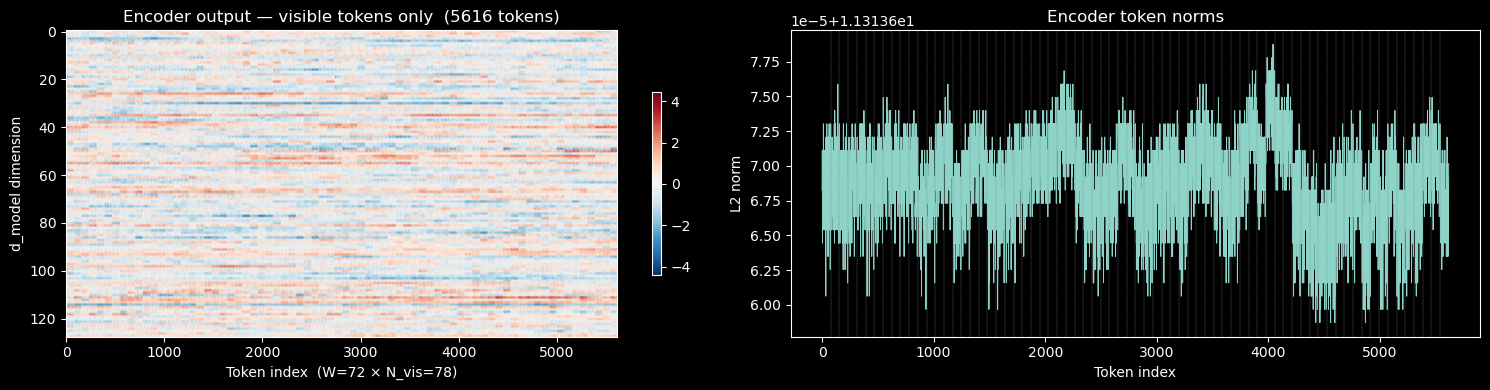

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Encoder output heatmap
ax = axes[0]
im = ax.imshow(encoded[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel(f"Token index  (W={W} × N_vis={N_vis})")
ax.set_ylabel("d_model dimension")
ax.set_title(f"Encoder output — visible tokens only  ({W*N_vis} tokens)")
for w in range(1, W):
    ax.axvline(w * N_vis, color="white", linewidth=0.3, alpha=0.4)
plt.colorbar(im, ax=ax, shrink=0.6)

# Token norms
ax2 = axes[1]
norms = encoded[0].norm(dim=-1).detach().numpy()   # (W*N_vis,)
ax2.plot(norms, linewidth=0.7)
ax2.set_xlabel("Token index")
ax2.set_ylabel("L2 norm")
ax2.set_title("Encoder token norms")
for w in range(1, W):
    ax2.axvline(w * N_vis, color="gray", linewidth=0.3, linestyle="--")

plt.tight_layout(); plt.show()

In [20]:
# DataLoader batch test — fixed_grid: y is (B, K=13, N, V)
loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
batch  = next(iter(loader))

print("DataLoader batch shapes (fixed_grid, K=13):")
for k, v in batch.items():
    print(f"  {k:<16} {tuple(v.shape) if isinstance(v, torch.Tensor) else v}")

# Run batch through encoder — unpack all 4 return values
encoder.eval()
with torch.no_grad():
    enc_out, m_idx, v_idx, input_ctx_b = encoder(
        x=batch["x"],
        x_mask=batch["x_mask"],
        spatial=batch["spatial"][0],   # (N, 15) — same across batch
        x_hours=batch["x_hours"],
    )
print(f"\nEncoder output (batch) : {tuple(enc_out.shape)}")
print(f"input_context  (batch) : {tuple(input_ctx_b.shape)}")

DataLoader batch shapes (fixed_grid, K=13):
  x                (8, 72, 156, 6)
  x_mask           (8, 72, 156, 6)
  x_hours          (8, 72)
  y                (8, 13, 156, 6)
  y_mask           (8, 13, 156, 6)
  y_hours          (8, 13)
  spatial          (8, 156, 15)
  delta_steps      (8, 13)

Encoder output (batch) : (8, 5616, 128)
input_context  (batch) : (8, 156, 128)


## Step 10 — Decoder forward pass

Key new parameters in v9:
- `window_size=WINDOW_SIZE` — used to place decoder query step indices at `W-1+Δ`
  (71, 74, 77, … 107 for Δ=0,3,6,…,36) continuing the encoder's 0..71 timeline
- `input_context_cross_attn` — optional final cross-attention to last-step tokens

The decoder handles both calling conventions automatically:
- **Single-delta**: `y_hours (B,)`, `delta_steps (B,)` → `(B, N, num_target_vars)`
- **Multi-delta** : `y_hours (B, K)`, `delta_steps (B, K)` → `(B, K, N, num_target_vars)` (one pass)

In [21]:
from model.decoder import StationMAEDecoder

decoder = StationMAEDecoder(
    d_model=D_MODEL, num_heads=DEC_HEADS, num_layers=DEC_LAYERS,
    mlp_ratio=MLP_RATIO, dropout=0.0,
    window_size=WINDOW_SIZE,           # needed for unified step-index timeline
)
print(f"Decoder parameters: {sum(p.numel() for p in decoder.parameters()):,}")

spatial_N15 = batch["spatial"][0]   # (N, 15)
K_batch = batch["delta_steps"].shape[1]  # 13

decoder.eval()
with torch.no_grad():
    # ── Single-delta (k=1 → delta=3 = 30 min, all-station forecast) ──────
    # We use k=1 (not k=0) since k=0 is the inpainting horizon (delta=0)
    # where the target == last input step — less interesting for visual demo.
    preds_1 = decoder(
        encoded_vis=enc_out,
        spatial=spatial_N15,
        y_hours=batch["y_hours"][:, 1],       # (B,)  30-min target
        delta_steps=batch["delta_steps"][:, 1],  # (B,)  delta=3
        input_context=input_ctx_b,             # (B, N, d_model)
    )
    print(f"Single-delta (k=1, Δ=3=30min) : {tuple(preds_1.shape)}   (B, N, num_target_vars)")

    # ── Multi-delta (all K=13 lead-times at once) ─────────────────────────
    preds_K = decoder(
        encoded_vis=enc_out,
        spatial=spatial_N15,
        y_hours=batch["y_hours"],             # (B, K=13)
        delta_steps=batch["delta_steps"],     # (B, K=13)
        input_context=input_ctx_b,
    )
    print(f"Multi-delta  (K={K_batch})              : {tuple(preds_K.shape)}   (B, K, N, num_target_vars)")
    print(f"  K=13 lead-times in ONE decoder pass ✓")
    print(f"  Decoder step indices: {(WINDOW_SIZE-1 + batch['delta_steps'][0]).tolist()}")
    print(f"  (encoder range 0..{WINDOW_SIZE-1}, decoder range {WINDOW_SIZE-1}..{WINDOW_SIZE-1+MAX_DELTA_STEPS})")

Decoder parameters: 498,309
Single-delta (k=1, Δ=3=30min) : (8, 156, 5)   (B, N, num_target_vars)
Multi-delta  (K=13)              : (8, 13, 156, 5)   (B, K, N, num_target_vars)
  K=13 lead-times in ONE decoder pass ✓
  Decoder step indices: [71, 74, 77, 80, 83, 86, 89, 92, 95, 98, 101, 104, 107]
  (encoder range 0..71, decoder range 71..107)


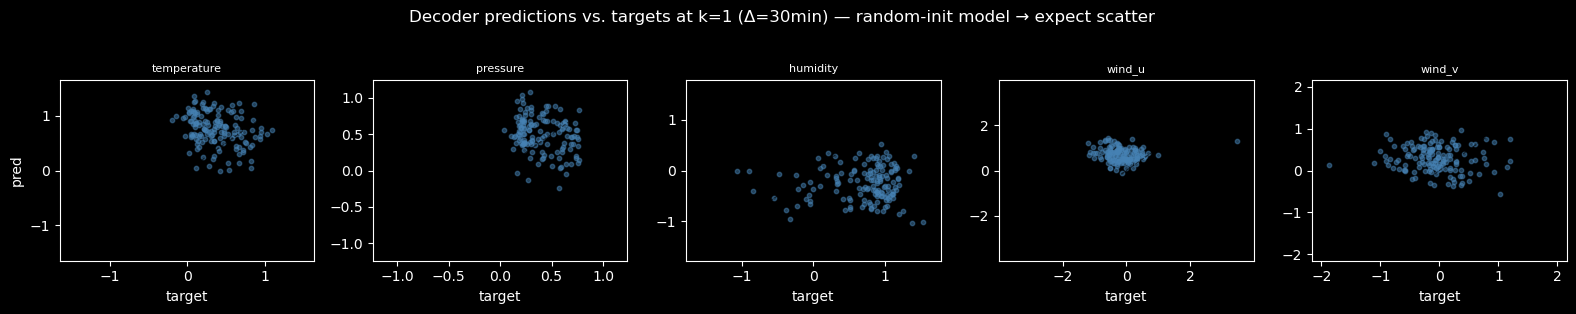

In [22]:
# Prediction vs target at k=1 (delta=3 = 30 min) — random-init model, expect scatter
from model.embeddings import TARGET_VARIABLE_NAMES, NUM_TARGET_VARIABLES

fig, axes = plt.subplots(1, NUM_TARGET_VARIABLES, figsize=(16, 3))
pred_0   = preds_1[0].detach().numpy()          # (N, NUM_TARGET_VARIABLES) — k=1
target_0 = batch["y"][0, 1].numpy()             # (N, V)  k=1 target
mask_0   = batch["y_mask"][0, 1].bool().numpy() # (N, V)  k=1 mask

for v, name in enumerate(TARGET_VARIABLE_NAMES):
    ax = axes[v]
    m  = mask_0[:, v]
    ax.scatter(target_0[m, v], pred_0[m, v], alpha=0.5, s=10, color="steelblue")
    lim = max(abs(target_0[m, v]).max(), abs(pred_0[m, v]).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("target"); ax.set_ylabel("pred") if v == 0 else None

plt.suptitle("Decoder predictions vs. targets at k=1 (Δ=30min) — random-init model → expect scatter", y=1.03)
plt.tight_layout(); plt.show()

## Step 11 — Full StationMAE forward pass

**Training path** (used by `main.py`): `forward_multi_delta` — encoder once, decoder once for all K=13 horizons.

**Val/monitoring path** (used by `lightning_module`): single-delta `forward` at k=1 (delta=3 = 30 min).

New constructor args in v9: `window_size=WINDOW_SIZE`, `use_nll_loss` (False here for simplicity),
`input_context_cross_attn`.

In [23]:
from model.mae import StationMAE

mae = StationMAE(
    d_model=D_MODEL, enc_heads=ENC_HEADS, enc_layers=ENC_LAYERS,
    dec_heads=DEC_HEADS, dec_layers=DEC_LAYERS, mlp_ratio=MLP_RATIO,
    dropout=0.0, mask_ratio=0.5,
    temporal_window=TEMPORAL_WINDOW,      # windowed attention, as trained
    cross_attention_decoder=True,         # queries cross-attend to encoder context
    window_size=WINDOW_SIZE,              # for unified step-index timeline
    input_context_cross_attn=True,        # decoder reads last-step encoder context
    use_nll_loss=False,                   # set True in full run (--nll_loss)
)
print(f"Total parameters  : {mae.count_parameters():,}")
enc_p = sum(p.numel() for p in mae.encoder.parameters() if p.requires_grad)
dec_p = sum(p.numel() for p in mae.decoder.parameters() if p.requires_grad)
print(f"  Encoder         : {enc_p:,}")
print(f"  Decoder         : {dec_p:,}")

# ── Multi-delta forward (K=13) — the TRAINING path ────────────────────────
# Encoder runs once; decoder runs once for all K=13 horizons (N×K queries).
train_batch_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_batch = next(iter(train_batch_loader))

mae.eval()
with torch.no_grad():
    loss_m, preds_m, masked_idx_m = mae.forward_multi_delta(
        x=train_batch["x"],
        x_mask=train_batch["x_mask"],
        spatial=train_batch["spatial"][0],
        x_hours=train_batch["x_hours"],
        y=train_batch["y"],                      # (B, K=13, N, V)
        y_mask=train_batch["y_mask"],
        y_hours=train_batch["y_hours"],          # (B, K=13)
        delta_steps=train_batch["delta_steps"],  # (B, K=13)
    )
K_actual = train_batch["delta_steps"].shape[1]
print(f"\n[Multi-delta forward  K={K_actual}]")
print(f"  Loss (weighted NxK horizons) : {loss_m.item():.5f}")
print(f"  Preds shape  : {tuple(preds_m.shape)}   (B, K, N, num_target_vars)")
print(f"  Delta steps  : {train_batch['delta_steps'][0].tolist()}")

# ── Single-delta forward at k=1 (Δ=30min) — the VAL MONITORING path ──────
# Val dataset also uses fixed_grid → slice to k=1 for single-delta forward
val_batch_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_batch = next(iter(val_batch_loader))

with torch.no_grad():
    loss_s, preds_s, masked_idx_s = mae(
        x=val_batch["x"],
        x_mask=val_batch["x_mask"],
        spatial=val_batch["spatial"][0],
        x_hours=val_batch["x_hours"],
        y=val_batch["y"][:, 1],              # (B, N, V)  — k=1 target (Δ=30min)
        y_mask=val_batch["y_mask"][:, 1],
        y_hours=val_batch["y_hours"][:, 1], # (B,)
        delta_steps=val_batch["delta_steps"][:, 1],  # (B,)  all=3
    )
print(f"\n[Single-delta val forward  k=1 (Δ=30min)]")
print(f"  Loss (MSE on all stations) : {loss_s.item():.5f}")
print(f"  Preds shape  : {tuple(preds_s.shape)}   (B, N, num_target_vars)")
print(f"  Masked idx   : {tuple(masked_idx_s.shape)}")

Total parameters  : 1,752,715
  Encoder         : 877,446
  Decoder         : 896,261

[Multi-delta forward  K=13]
  Loss (weighted NxK horizons) : 0.46344
  Preds shape  : (8, 13, 156, 5)   (B, K, N, num_target_vars)
  Delta steps  : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]

[Single-delta val forward  k=1 (Δ=30min)]
  Loss (MSE on all stations) : 0.60521
  Preds shape  : (8, 156, 5)   (B, N, num_target_vars)
  Masked idx   : (8, 78)


### NLL variant — predicted uncertainty (σ)

With `use_nll_loss=True` the decoder gains a second head predicting **log σ²**, and
`forward_multi_delta(..., return_log_var=True)` returns it alongside the mean. This is
what v9 was trained with, and what the evaluation now persists into `predictions.pt`.

In [24]:
# ── NLL model: mean + predicted uncertainty ─────────────────────────────────
mae_nll = StationMAE(
    d_model=D_MODEL, enc_heads=ENC_HEADS, enc_layers=ENC_LAYERS,
    dec_heads=DEC_HEADS, dec_layers=DEC_LAYERS, mlp_ratio=MLP_RATIO,
    dropout=0.0, mask_ratio=0.5,
    temporal_window=TEMPORAL_WINDOW,
    cross_attention_decoder=True,
    window_size=WINDOW_SIZE,
    input_context_cross_attn=True,
    use_nll_loss=True,                      # ← adds decoder.log_var_head
)
has_head = any("log_var_head" in n for n, _ in mae_nll.named_parameters())
print(f"log_var_head present: {has_head}")

mae_nll.eval()
with torch.no_grad():
    loss_n, preds_n, midx_n, log_var_n = mae_nll.forward_multi_delta(
        train_batch["x"], train_batch["x_mask"], train_batch["spatial"][0],
        train_batch["x_hours"], train_batch["y"], train_batch["y_mask"],
        train_batch["y_hours"], train_batch["delta_steps"],
        return_log_var=True,                # ← 4-tuple; default False keeps 3-tuple
    )
sigma = torch.exp(0.5 * log_var_n)          # σ in normalised space
print(f"preds   : {tuple(preds_n.shape)}")
print(f"log_var : {tuple(log_var_n.shape)}")
print(f"σ range : {sigma.min():.3f} … {sigma.max():.3f}   (≈1.0 at init — head starts at zero)")

# how σ is expected to behave once trained: grow with lead time
sig_by_k = sigma.mean(dim=(0, 2, 3))        # (K,)
print("\nmean σ by horizon:", [f"{v:.3f}" for v in sig_by_k.tolist()])
print("(random-init model — flat here; on a trained NLL model this should increase with lead time)")

log_var_head present: True
preds   : (8, 13, 156, 5)
log_var : (8, 13, 156, 5)
σ range : 1.000 … 1.000   (≈1.0 at init — head starts at zero)

mean σ by horizon: ['1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000', '1.000']
(random-init model — flat here; on a trained NLL model this should increase with lead time)


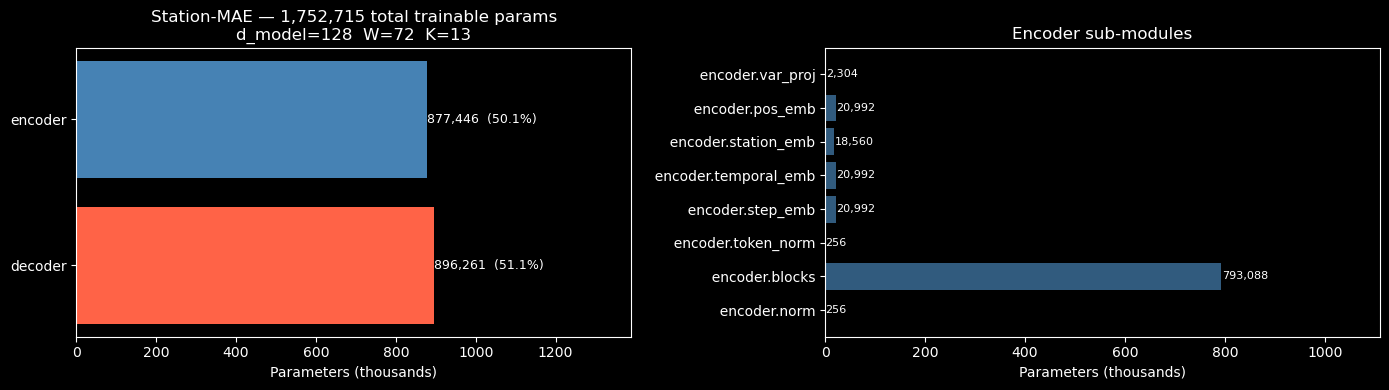


Station-MAE parameter breakdown:
Module                             Params   % total
----------------------------------------------------
  encoder                         877,446     50.1%
  decoder                         896,261     51.1%
TOTAL                           1,752,715    100.0%


In [25]:
# ── Module-level parameter breakdown ─────────────────────────────────────
rows = []
for child_name, child_module in mae.named_children():
    p = sum(param.numel() for param in child_module.parameters() if param.requires_grad)
    rows.append((child_name, p))

enc_rows = []
for child_name, child_module in mae.encoder.named_children():
    p = sum(param.numel() for param in child_module.parameters() if param.requires_grad)
    enc_rows.append((f"  encoder.{child_name}", p))

total = mae.count_parameters()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
labels = [r[0] for r in rows]
vals   = [r[1] for r in rows]
colors = ["steelblue", "tomato", "seagreen"][:len(labels)]
bars = ax.barh(labels, [v / 1000 for v in vals], color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({100*v/total:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Parameters (thousands)")
ax.set_title(f"Station-MAE — {total:,} total trainable params\n"
             f"d_model={D_MODEL}  W={WINDOW_SIZE}  K={K_actual}")
ax.set_xlim(0, max(vals) / 1000 * 1.55)
ax.invert_yaxis()

ax2 = axes[1]
elabels = [r[0] for r in enc_rows]
evals   = [r[1] for r in enc_rows]
if evals:
    ebars = ax2.barh(elabels, [v / 1000 for v in evals], color="steelblue", alpha=0.7)
    for bar, v in zip(ebars, evals):
        ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}", va="center", fontsize=8)
    ax2.set_xlabel("Parameters (thousands)")
    ax2.set_title("Encoder sub-modules")
    ax2.set_xlim(0, max(evals) / 1000 * 1.4)
    ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nStation-MAE parameter breakdown:")
print(f"{'Module':<30} {'Params':>10}  {'% total':>8}")
print("-" * 52)
for name, p in rows:
    print(f"  {name:<28} {p:>10,}  {100*p/total:>7.1f}%")
print(f"{'TOTAL':<30} {total:>10,}  {'100.0%':>8}")

In [26]:
_USE_WANDB_HERE = False   # ← set to True to activate

if _USE_WANDB_HERE:
    import wandb
    run = wandb.init(project="station-mae-dev", name="notebook-arch-explore",
                     config={"d_model": D_MODEL, "enc_layers": 4, "dec_layers": 2,
                             "window_size": WINDOW_SIZE, "K": K_actual})
    param_table = wandb.Table(
        columns=["module", "params", "pct_total"],
        data=[(name, p, round(100 * p / total, 2)) for name, p in rows],
    )
    run.log({"architecture/param_breakdown": param_table,
             "architecture/total_params": total})
    wandb.watch(mae, log="gradients", log_freq=50)
    print("wandb.watch() registered")
    run.finish()
else:
    print("WandB demo skipped — set _USE_WANDB_HERE = True and run wandb login to activate")
    print("\nDuring main.py training with --wandb_project station-mae:")
    print("  • train/loss is logged per step (on_step=True, on_epoch=False)")
    print("  • train/overall_rmse at k=1 (Δ=30min) is logged per epoch")
    print("  • val/loss (NLL), val/overall_rmse, val/{var}_rmse_phys logged per epoch")
    print("  • val/horizon_sensitivity = mean|pred(Δ=6h) - pred(Δ=30min)| on batch 0")

WandB demo skipped — set _USE_WANDB_HERE = True and run wandb login to activate

During main.py training with --wandb_project station-mae:
  • train/loss is logged per step (on_step=True, on_epoch=False)
  • train/overall_rmse at k=1 (Δ=30min) is logged per epoch
  • val/loss (NLL), val/overall_rmse, val/{var}_rmse_phys logged per epoch
  • val/horizon_sensitivity = mean|pred(Δ=6h) - pred(Δ=30min)| on batch 0


## Step 12 — Mini-training with PyTorch Lightning (sanity check)

Trains a **tiny model** (d=64, 2+1 layers) on a small random subset.
Uses `fixed_grid` delta mode (K=13) matching the real training setup.
Expected: loss decreases, no NaNs, all checkpoint files appear.

In [27]:
from model.mae import StationMAE
from model.lightning_module import StationMAELightning

# ── Tiny model ────────────────────────────────────────────────────────────
MINI_D       = 64
MINI_EPOCHS  = 10
MINI_SUBSET  = 256   # training samples
MINI_VAL_SUB = 64    # validation samples

mini_model = StationMAE(
    d_model=MINI_D, enc_heads=4, enc_layers=2,
    dec_heads=4, dec_layers=1, mlp_ratio=2.0,
    dropout=0.1, mask_ratio=0.5,
    window_size=WINDOW_SIZE,           # must match the dataset window_size
    input_context_cross_attn=True,
    use_nll_loss=False,               # keep simple for sanity check
)
print(f"Mini-model parameters: {mini_model.count_parameters():,}")

# ── Subset DataLoaders ────────────────────────────────────────────────────
n_sub          = min(MINI_SUBSET, len(train_ds))
perm           = torch.randperm(len(train_ds))[:n_sub].tolist()
mini_train_sub = Subset(train_ds, perm)

n_val          = min(MINI_VAL_SUB, len(val_ds))
mini_val_sub   = Subset(val_ds, list(range(n_val)))

mini_train_loader = DataLoader(mini_train_sub, batch_size=8, shuffle=True,
                               num_workers=0, drop_last=True)
mini_val_loader   = DataLoader(mini_val_sub,   batch_size=8, shuffle=False,
                               num_workers=0)

print(f"Train subset : {len(mini_train_sub)} samples  "
      f"({len(mini_train_loader)} batches/epoch, K={K_actual})")
print(f"Val   subset : {len(mini_val_sub)} samples  "
      f"({len(mini_val_loader)} batches/epoch, K={K_actual})")
print(f"Batch shapes — y: (B={8}, K={K_actual}, N, V)")

# ── Training config ───────────────────────────────────────────────────────
mini_cfg = {
    "lr":            1e-3,
    "weight_decay":  0.05,
    "epochs":        MINI_EPOCHS,
    "warmup_epochs": 1,
    "min_lr":        1e-6,
    "log_every_n_steps": 1,
}

# ── Lightning module ──────────────────────────────────────────────────────
mini_lit = StationMAELightning(model=mini_model, cfg=mini_cfg)

# ── Logger ────────────────────────────────────────────────────────────────
os.makedirs(MINI_SAVE_DIR, exist_ok=True)
mini_logger = CSVLogger(save_dir=MINI_SAVE_DIR, name="logs", version=0)

# ── Callbacks ─────────────────────────────────────────────────────────────
mini_callbacks = [
    ModelCheckpoint(
        dirpath=MINI_SAVE_DIR,
        filename="best",
        monitor="val/loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        verbose=True,
    ),
    EarlyStopping(
        monitor="val/loss",
        patience=5,
        min_delta=1e-4,
        mode="min",
        verbose=True,
    ),
    LearningRateMonitor(logging_interval="step"),
]

print(f"\nCheckpoints → {os.path.abspath(MINI_SAVE_DIR)}")
print(f"CSV logs    → {os.path.abspath(os.path.join(MINI_SAVE_DIR, 'logs', 'version_0'))}")

Mini-model parameters: 200,587
Train subset : 256 samples  (32 batches/epoch, K=13)
Val   subset : 64 samples  (8 batches/epoch, K=13)
Batch shapes — y: (B=8, K=13, N, V)

Checkpoints → /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/checkpoints_mini
CSV logs    → /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/checkpoints_mini/logs/version_0


In [28]:
mini_trainer = pl.Trainer(
    max_epochs=MINI_EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="32-true",
    gradient_clip_val=1.0,
    callbacks=mini_callbacks,
    logger=mini_logger,
    log_every_n_steps=1,
    enable_progress_bar=True,
)

mini_trainer.fit(
    model=mini_lit,
    train_dataloaders=mini_train_loader,
    val_dataloaders=mini_val_loader,
)
print("\nMini-training complete ✓")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/checkpoints_mini exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' do

┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ StationMAE │  200 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 200 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 200 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 120                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:43
4: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.

RuntimeError: MPS backend out of memory (MPS allocated: 23.84 GiB, other allocations: 19.30 GiB, max allowed: 45.90 GiB). Tried to allocate 6.97 GiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## Step 12b — Inspect saved checkpoints and Lightning CSV log

In [29]:
# ── Checkpoint files ─────────────────────────────────────────────────────
print(f"Checkpoint files in {MINI_SAVE_DIR}/")
for fn in sorted(os.listdir(MINI_SAVE_DIR)):
    fp = os.path.join(MINI_SAVE_DIR, fn)
    if os.path.isfile(fp):
        size_kb = os.path.getsize(fp) / 1024
        print(f"  {fn:<30}  {size_kb:6.1f} KB")

# ── Lightning CSV log ─────────────────────────────────────────────────────
log_path = os.path.join(MINI_SAVE_DIR, "logs", "version_0", "metrics.csv")
logs_raw = pd.read_csv(log_path)
print(f"\nAll columns in metrics.csv: {list(logs_raw.columns)}")

# train/loss is logged on_step=True, on_epoch=False → no epoch aggregate column.
# val metrics are logged on_epoch=True → appear in rows where epoch advances.
# Extract epoch-level summary from rows where val/loss is present.
epoch_logs = (
    logs_raw
    .dropna(subset=["val/loss"])
    .copy()
)

# Add step-level train/loss average per epoch for display
step_train = logs_raw.dropna(subset=["train/loss"]).copy()
if "epoch" in step_train.columns:
    train_per_epoch = step_train.groupby("epoch")["train/loss"].mean().reset_index()
    train_per_epoch.rename(columns={"train/loss": "train_loss_mean"}, inplace=True)
    epoch_logs = epoch_logs.merge(train_per_epoch, on="epoch", how="left")

display_cols = [c for c in ["epoch", "train_loss_mean", "val/loss", "val/overall_rmse",
                             "val/temperature_rmse"] if c in epoch_logs.columns]
print(f"\nEpoch-level summary ({len(epoch_logs)} epochs):")
try:
    from IPython.display import display
    display(epoch_logs[display_cols].round(5).reset_index(drop=True))
except ImportError:
    print(epoch_logs[display_cols].round(5).to_string())

# ── Loss curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

ax = axes[0]
if "train_loss_mean" in epoch_logs.columns:
    ax.plot(epoch_logs["epoch"], epoch_logs["train_loss_mean"], "o-",
            color="steelblue", label="train (epoch mean)")
ax.plot(epoch_logs["epoch"], epoch_logs["val/loss"], "s--",
        color="tomato", label="val")
best_ep = epoch_logs.loc[epoch_logs["val/loss"].idxmin(), "epoch"]
ax.axvline(best_ep, color="green", lw=1.2, ls=":", label=f"best (ep {int(best_ep)})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Train / Val Loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
if "val/overall_rmse" in epoch_logs.columns:
    ax.plot(epoch_logs["epoch"], epoch_logs["val/overall_rmse"], "D-", color="darkorange")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val overall RMSE (norm)")
ax.set_title("Validation RMSE (all stations, k=1=30min)"); ax.grid(alpha=0.3)

# Step-level train loss
if not step_train.empty and "step" in step_train.columns:
    ax = axes[2]
    ax.plot(step_train["step"], step_train["train/loss"],
            linewidth=0.8, color="slategray", alpha=0.8)
    ax.set_xlabel("Step"); ax.set_ylabel("Train loss (per step)")
    ax.set_title("Train loss — step level"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_val = epoch_logs["val/loss"].min()
print(f"\nBest val/loss = {best_val:.5f}  at epoch {int(best_ep)}")

Checkpoint files in ./checkpoints_mini/

All columns in metrics.csv: ['lr-AdamW/pg1', 'lr-AdamW/pg2', 'step']


KeyError: ['val/loss']

## Step 13 — Quick evaluation on val subset

Val batches use fixed_grid (K=13). We evaluate at **k=1 (Δ=30 min, all stations)**
to match the val/overall_rmse metric logged during training.

In [ ]:
# Load best checkpoint
best_ckpt_path = os.path.join(MINI_SAVE_DIR, "best.ckpt")
if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    sd = {k[len("model."):]: v
          for k, v in ckpt["state_dict"].items()
          if k.startswith("model.")}
    mini_model.load_state_dict(sd)
    print(f"Loaded best.ckpt  (epoch {ckpt.get('epoch', '?')})")
else:
    print(f"best.ckpt not found — evaluating current weights")

# ── Evaluate at k=1 (Δ=30min) across val subset ──────────────────────────
N_VAL_SUB  = min(128, len(val_ds))
val_sub    = Subset(val_ds, list(range(N_VAL_SUB)))
val_loader = DataLoader(val_sub, batch_size=8, shuffle=False, num_workers=0)

mini_model.eval().to(device)
tot_loss, n_batches = 0.0, 0
with torch.no_grad():
    for b in val_loader:
        sp = b["spatial"][0].to(device)
        # Fixed-grid: slice to k=1 (Δ=30min) for single-delta forward
        loss_v, _, _ = mini_model(
            b["x"].to(device), b["x_mask"].to(device), sp,
            b["x_hours"].to(device),
            b["y"][:, 1].to(device),            # (B, N, V)  k=1
            b["y_mask"][:, 1].to(device),
            b["y_hours"][:, 1].to(device),      # (B,)
            b["delta_steps"][:, 1].to(device),  # (B,)
        )
        tot_loss += loss_v.item()
        n_batches += 1

print(f"Val MSE (Δ=30min, k=1, norm) = {tot_loss / max(n_batches, 1):.5f}")
print(f"Val RMSE (approx)             = {(tot_loss / max(n_batches, 1))**0.5:.5f}  (normalised)")

In [ ]:
# Scatter: predicted vs. true at k=1 (Δ=30min) for all target variables
# Loop uses single-delta forward — slicing to k=1 from fixed_grid batches.
mini_model.eval()
all_preds, all_targets, all_masks = [], [], []

with torch.no_grad():
    for b in val_loader:
        sp = b["spatial"][0].to(device)
        # Slice k=1 (Δ=30min) for all-station single-delta forward
        _, preds_v, m_idx_v = mini_model(
            b["x"].to(device), b["x_mask"].to(device), sp,
            b["x_hours"].to(device),
            b["y"][:, 1].to(device),
            b["y_mask"][:, 1].to(device),
            b["y_hours"][:, 1].to(device),
            b["delta_steps"][:, 1].to(device),
        )
        # Collect predictions for ALL stations (not just masked)
        all_preds.append(preds_v.cpu())
        all_targets.append(b["y"][:, 1, :, :NUM_TARGET_VARIABLES])   # (B, N, V_t)
        all_masks.append(b["y_mask"][:, 1, :, :NUM_TARGET_VARIABLES].bool())

P  = torch.cat(all_preds).reshape(-1, NUM_TARGET_VARIABLES)    # (total_BN, V)
T_ = torch.cat(all_targets).reshape(-1, NUM_TARGET_VARIABLES)
M  = torch.cat(all_masks).reshape(-1, NUM_TARGET_VARIABLES)

fig, axes = plt.subplots(1, NUM_TARGET_VARIABLES, figsize=(16, 3))
for v, name in enumerate(TARGET_VARIABLE_NAMES):
    ax = axes[v]
    mv = M[:, v]
    pv = P[mv, v].numpy()
    tv = T_[mv, v].numpy()
    ax.scatter(tv, pv, alpha=0.3, s=6, rasterized=True, color="steelblue")
    lim = max(abs(tv).max(), abs(pv).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    rmse = float(((pv - tv) ** 2).mean() ** 0.5)
    ax.set_title(f"{name}\nRMSE={rmse:.3f} (norm)", fontsize=8)
    ax.set_xlabel("target")
    if v == 0:
        ax.set_ylabel("pred")

plt.suptitle(
    f"Val predictions vs. targets — k=1 (Δ=30min, all stations)  "
    f"W={WINDOW_SIZE}×10min = 12h input",
    y=1.03, fontsize=9,
)
plt.tight_layout()
plt.show()

---
## All steps passed ✓

The full stack — data loading → spatial/temporal/step embeddings → encoder (4-tuple return)
→ decoder (K=13 fixed-grid queries) → loss → backward — runs correctly.

**Key v9 changes verified:**
- W=72 (12h input), K=13 fixed-grid horizons [0, 30min, … 6h]
- Encoder returns `(encoded, masked_idx, visible_idx, input_context)` — 4 values
- Decoder uses `window_size=72` for unified step-index timeline (enc 0..71, dec 74..107)
- `input_context` zeros for masked stations — no leakage
- Val monitoring at k=1 (Δ=30min, all stations) matches `val/overall_rmse` in WandB

Next: launch the full run with `./run_full_cloud.sh`